Game 1000: Epsilon: 0.9049, Avg Q1: 16.06, Avg Q2: 15.858


AttributeError: module 'torch' has no attribute 'FloatFloatTensor'

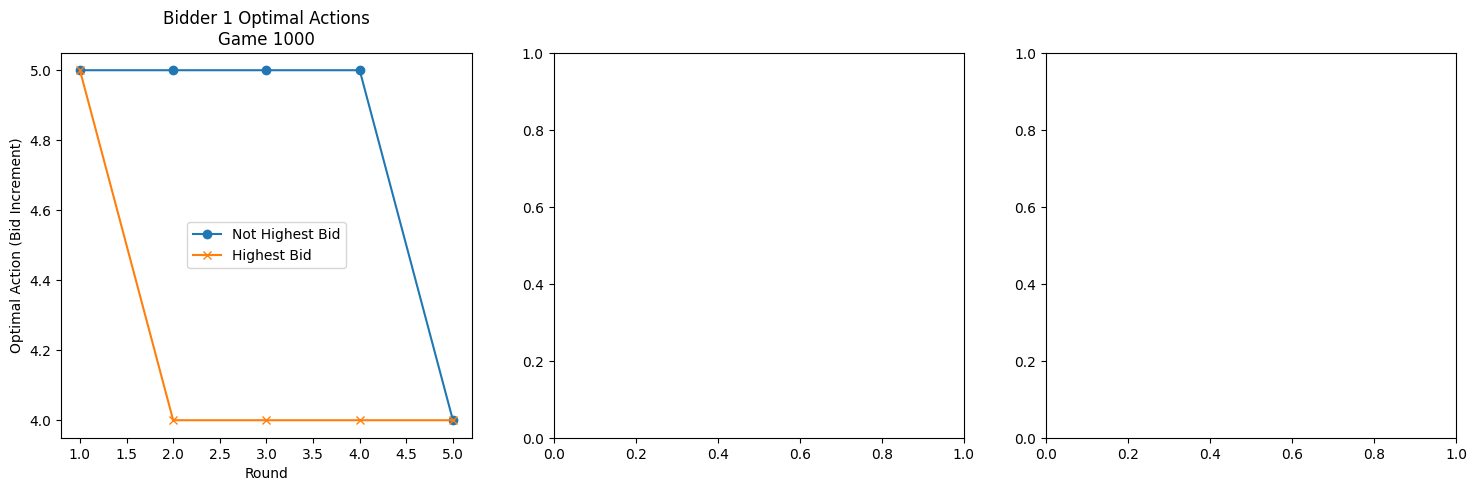

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Parameters
num_rounds = 5
valuation = 50
num_actions = 6
actions = np.arange(num_actions)
epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay = 0.9999
learning_rate = 0.001
discount_rate = 1.0
lambda_ = 0.9
num_games = 10000
verbose_interval = 1000
batch_size = 64
replay_buffer_size = 64
target_update_frequency = 64

# Define the DQN network
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Initialize Q-networks
input_dim = 2  # num_rounds and state (whether player has the highest bid)
output_dim = num_actions
q_network1 = DQN(input_dim, output_dim)
q_network2 = DQN(input_dim, output_dim)
target_network1 = DQN(input_dim, output_dim)
target_network2 = DQN(input_dim, output_dim)
target_network1.load_state_dict(q_network1.state_dict())
target_network2.load_state_dict(q_network2.state_dict())

# Optimizers
optimizer1 = optim.Adam(q_network1.parameters(), lr=learning_rate)
optimizer2 = optim.Adam(q_network2.parameters(), lr=learning_rate)

# Replay buffers
replay_buffer1 = deque(maxlen=replay_buffer_size)
replay_buffer2 = deque(maxlen=replay_buffer_size)

# Function to sample from replay buffer
def sample_from_buffer(buffer, batch_size):
    return random.sample(buffer, batch_size)

# Function to select action (epsilon-greedy)
def select_action(state, epsilon, q_network):
    if np.random.rand() < epsilon:
        return np.random.choice(actions)
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = q_network(state_tensor)
            return torch.argmax(q_values).item()

# Function to train the DQN
def train_dqn(replay_buffer, q_network, target_network, optimizer):
    if len(replay_buffer) < batch_size:
        return

    batch = sample_from_buffer(replay_buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states_tensor = torch.FloatTensor(states)
    actions_tensor = torch.LongTensor(actions).unsqueeze(1)
    rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1)
    next_states_tensor = torch.FloatTensor(next_states)
    dones_tensor = torch.FloatTensor(dones).unsqueeze(1)

    q_values = q_network(states_tensor).gather(1, actions_tensor)
    next_q_values = target_network(next_states_tensor).max(1)[0].unsqueeze(1)
    targets = rewards_tensor + discount_rate * next_q_values * (1 - dones_tensor)

    loss = nn.MSELoss()(q_values, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Function to plot optimal actions and a simulated game
def plot_optimal_actions_and_simulated_game(game_count, q_network1, q_network2):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot optimal actions for Bidder 1
    optimal_actions_bidder1_no_highest = []
    optimal_actions_bidder1_highest = []
    for t in range(1, num_rounds + 1):
        state_no_highest = np.array([t, 0])  # Not the highest bid
        state_highest = np.array([t, 1])     # Is the highest bid
        with torch.no_grad():
            state_tensor_no_highest = torch.FloatTensor(state_no_highest).unsqueeze(0)
            state_tensor_highest = torch.FloatTensor(state_highest).unsqueeze(0)
            q_values_no_highest = q_network1(state_tensor_no_highest).numpy().squeeze()
            q_values_highest = q_network1(state_tensor_highest).numpy().squeeze()
            optimal_actions_bidder1_no_highest.append(np.argmax(q_values_no_highest))
            optimal_actions_bidder1_highest.append(np.argmax(q_values_highest))
    
    axes[0].plot(range(1, num_rounds + 1), optimal_actions_bidder1_no_highest, label="Not Highest Bid", marker='o')
    axes[0].plot(range(1, num_rounds + 1), optimal_actions_bidder1_highest, label="Highest Bid", marker='x')
    axes[0].set_title(f'Bidder 1 Optimal Actions\nGame {game_count}')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Optimal Action (Bid Increment)')
    axes[0].legend()

    # Plot optimal actions for Bidder 2
    optimal_actions_bidder2_no_highest = []
    optimal_actions_bidder2_highest = []
    for t in range(1, num_rounds + 1):
        state_no_highest = np.array([t, 0])  # Not the highest bid
        state_highest = np.array([t, 1])     # Is the highest bid
        with torch.no_grad():
            state_tensor_no_highest = torch.FloatTensor(state_no_highest).unsqueeze(0)
            state_tensor_highest = torch.FloatFloatTensor(state_highest).unsqueeze(0)
            q_values_no_highest = q_network2(state_tensor_no_highest).numpy().squeeze()
            q_values_highest = q_network2(state_tensor_highest).numpy().squeeze()
            optimal_actions_bidder2_no_highest.append(np.argmax(q_values_no_highest))
            optimal_actions_bidder2_highest.append(np.argmax(q_values_highest))
    
    axes[1].plot(range(1, num_rounds + 1), optimal_actions_bidder2_no_highest, label="Not Highest Bid", marker='o')
    axes[1].plot(range(1, num_rounds + 1), optimal_actions_bidder2_highest, label="Highest Bid", marker='x')
    axes[1].set_title(f'Bidder 2 Optimal Actions\nGame {game_count}')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('Optimal Action (Bid Increment)')
    axes[1].legend()

    # Simulate and plot a single game
    highest_bids_q1, highest_bids_q2 = simulate_single_game(q_network1, q_network2)
    axes[2].plot(range(1, num_rounds + 1), highest_bids_q1, 'x-', label='Agent 1 Highest Bids', markersize=8)
    axes[2].plot(range(1, num_rounds + 1), highest_bids_q2, 'o-', label='Agent 2 Highest Bids', markersize=5)
    axes[2].set_title(f'Bids in Single Game (Game {game_count})')
    axes[2].set_xlabel('Round')
    axes[2].set_ylabel('Highest Bid Amount')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Simulate a single game
def simulate_single_game(q_network1, q_network2):
    t = num_rounds
    s = 0
    current_bid_q1 = 0
    current_bid_q2 = 0
    highest_bids_q1 = []
    highest_bids_q2 = []

    while t > 0:
        state_q1 = np.array([t, s])
        state_q2 = np.array([t, 1 - s])

        action_q1 = select_action(state_q1, epsilon_min, q_network1)
        action_q2 = select_action(state_q2, epsilon_min, q_network2)

        current_bid_q1 += action_q1
        current_bid_q2 += action_q2

        highest_bids_q1.append(current_bid_q1)
        highest_bids_q2.append(current_bid_q2)

        # If there's a tie, pick the winner randomly
        if current_bid_q1 == current_bid_q2:
            s = np.random.choice([0, 1])  # Randomly assign the winner
        else:
            s = 1 if current_bid_q1 >= current_bid_q2 else 0

        t -= 1

    return highest_bids_q1, highest_bids_q2

# Train function for two agents using DQN
def train_agents_dqn():
    epsilon = epsilon_start
    reward_history_q1 = []
    reward_history_q2 = []

    for game in range(num_games):
        t = num_rounds
        s = 0
        current_bid_q1 = 0
        current_bid_q2 = 0
        done = False

        while t > 0:
            state_q1 = np.array([t, s])
            state_q2 = np.array([t, 1 - s])

            action_q1 = select_action(state_q1, epsilon, q_network1)
            action_q2 = select_action(state_q2, epsilon, q_network2)

            current_bid_q1 += action_q1
            current_bid_q2 += action_q2

            # If there's a tie, pick the winner randomly
            if current_bid_q1 == current_bid_q2:
                s = np.random.choice([0, 1])  # Randomly assign the winner
            else:
                s = 1 if current_bid_q1 >= current_bid_q2 else 0

            next_state_q1 = np.array([t-1, s])
            next_state_q2 = np.array([t-1, 1 - s])

            reward_q1 = (valuation - current_bid_q1) if (current_bid_q1 > current_bid_q2) and (current_bid_q1 <= valuation) else 0
            reward_q2 = (valuation - current_bid_q2) if (current_bid_q2 > current_bid_q1) and (current_bid_q2 <= valuation) else 0

            replay_buffer1.append((state_q1, action_q1, reward_q1, next_state_q1, done))
            replay_buffer2.append((state_q2, action_q2, reward_q2, next_state_q2, done))

            train_dqn(replay_buffer1, q_network1, target_network1, optimizer1)
            train_dqn(replay_buffer2, q_network2, target_network2, optimizer2)

            t -= 1

        reward_history_q1.append(reward_q1)
        reward_history_q2.append(reward_q2)

        # Plot optimal actions and simulate a game
        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q1: {np.mean(reward_history_q1[-verbose_interval:])}, Avg Q2: {np.mean(reward_history_q2[-verbose_interval:])}")
            plot_optimal_actions_and_simulated_game(game + 1, q_network1, q_network2)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (game + 1) % target_update_frequency == 0:
            target_network1.load_state_dict(q_network1.state_dict())
            target_network2.load_state_dict(q_network2.state_dict())

    return q_network1, q_network2, reward_history_q1, reward_history_q2

# Train the agents
q_network1, q_network2, reward_history_q1, reward_history_q2 = train_agents_dqn()


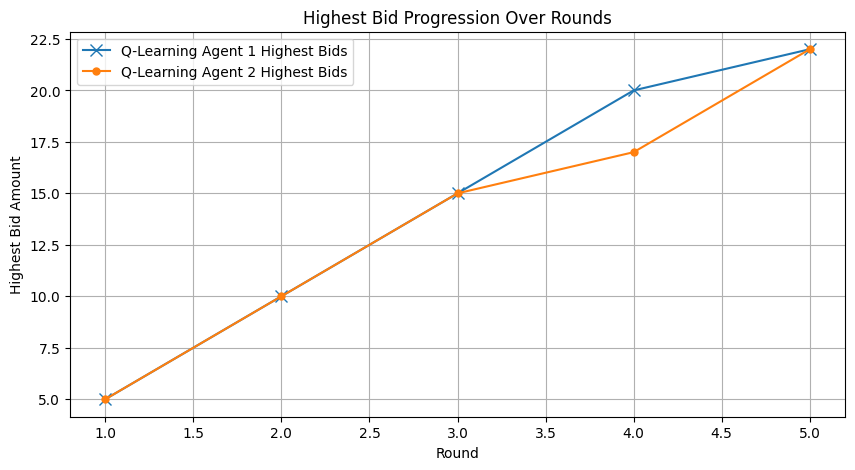

Reward for DQN Agent 1: 0
Reward for DQN Agent 2: 0


In [11]:
visualize_game(highest_bids_q1, highest_bids_q2)
print(f"Reward for DQN Agent 1: {reward_q1}")
print(f"Reward for DQN Agent 2: {reward_q2}")